# The Differentiable OED Moat — *design the experiment by gradient*

**Thesis (one line).** Because NUDGE's forward model is a **differentiable** JAX program, the
Fisher-information design criterion is itself a differentiable function of *the experiment*,
so NUDGE takes `∂(D-optimality)/∂φ` **by autodiff** and gradient-ascends the measurement
schedule `φ` to the exact optimal experiment — resolving a parameter that was **31.5×**
sloppier under the naive design. A legacy black-box ODE solver has **no** `∂/∂φ`; it can only
grid-search, which is exponential in the design size. And NUDGE does this while the underlying
identifiability analysis (the FIM = `JᵀJ`) scales **matrix-free**, past the point where
materializing `J` runs a machine out of memory.

This notebook ties the moat together in three moves:

1. **The baseline** — the naive "measure at steady state" design is *near-singular*: growth `α`
   and self-limitation `β` are confounded. A black box can only *sample* better designs.
2. **The moat** — NUDGE's exact `∂(D-optimality)/∂φ` gradient ascends `φ` to the optimum in one
   pass: **CRLB(α) 31.3× better** (targeted objective: **31.5×**), FIM smallest eigenvalue
   17.5× better.
3. **At scale** — the very FIM the OED gradient differentiates is `JᵀJ`; NUDGE computes it
   **matrix-free**, staying flat in memory where the dense `jacfwd` path OOMs.

**Honesty up front (a feature, not fine print).** This is **local** optimal experimental design
(`NUDGE-LIM-024`): the FIM is the likelihood curvature at a *nominal* `θ₀`, so the optimal design
and every reported gain are valid near `θ₀` and are **measured there, not extrapolated**.
Near-singular FIMs are inverted with a guarded ridge (never a plain pseudo-inverse, which would
*understate* the bound), and a black-box grid search is shipped to **check** the gradient
optimum. The matrix-free path (`NUDGE-LIM-023`) *abstains* on the smallest FIM eigenvalue it
cannot certify by iteration rather than assert it.

In [1]:
import warnings
warnings.filterwarnings("ignore")  # JAX/CUDA fallback chatter is noise in a demo

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from nudge.inference import oed

np.set_printoptions(precision=3, suppress=True)
print("NUDGE optimal-experimental-design demo — differentiable white-box OED")

NUDGE optimal-experimental-design demo — differentiable white-box OED


## 1 · The baseline — "measure at steady state" is near-singular

The showcase model is single-species **logistic growth** `dx/dt = x·(α + β·x)` (`β < 0`), the
canonical growth ⇄ carrying-capacity degeneracy. Its steady state is `K = −α/β`, so **measuring
only near equilibrium leaves `α` and `β` confounded** — any `(α, β)` sharing the same `K` fits
the plateau equally well. The *transient* climbs at rate ≈ `α` and is what separates them.

We build the design problem, then score the **naive near-equilibrium design**: 8 measurements
spread over the last 40 % of the window (the realistic "wait for it to settle, then sample"
default). We read off the Fisher-information matrix's condition number, smallest eigenvalue, and
the Cramér–Rao lower bound on `α`.

In [2]:
prob = oed.make_logistic_design_problem()      # α=0.8, β=−0.4  ⇒  K = 2
t_max = prob.meta["t_max"]

# naive design: 8 samples clustered near equilibrium (the last 40% of the window)
phi_naive = np.linspace(0.6 * t_max, t_max, 8)

fim_naive = oed.fisher_information(prob, phi_naive)
cond_naive = float(np.linalg.cond(fim_naive))
mineig_naive = oed.min_eigenvalue(fim_naive)
crlb_naive = oed.crlb(fim_naive)[prob.param_index("log_alpha")]

print(f"naive near-equilibrium design  φ = {np.round(phi_naive, 2)}")
print(f"  FIM condition number   : {cond_naive:8.1f}   (large ⇒ sloppy/ill-conditioned)")
print(f"  FIM smallest eigenvalue: {mineig_naive:8.1f}   (the α⇄β sloppy direction)")
print(f"  CRLB(α)                : {crlb_naive:.3e}   (variance floor on the growth rate)")

naive near-equilibrium design  φ = [ 7.2   7.89  8.57  9.26  9.94 10.63 11.31 12.  ]
  FIM condition number   :    136.4   (large ⇒ sloppy/ill-conditioned)
  FIM smallest eigenvalue:     54.3   (the α⇄β sloppy direction)
  CRLB(α)                : 7.341e-03   (variance floor on the growth rate)


### What a black box can do about it: *sample*

A legacy solver with no `∂criterion/∂φ` can only **evaluate** candidate designs and keep the
best. On a **1-D** design knob (5 samples pinned at equilibrium, one free transient time `t₁`)
that is affordable — a 200-point grid finds the optimum. But the cost of *guaranteeing* the
optimum by structured grid is `rᵐ` FIM evaluations for `m` free times — it explodes.

In [3]:
# 1-D black-box grid search over a single free transient time t1
grid_t1 = np.linspace(prob.phi_bounds[0], t_max, 200)
candidates = [np.concatenate([[t1], np.full(5, t_max)]) for t1 in grid_t1]
grid = oed.grid_search_design(prob, candidates, objective="d_opt", target="log_alpha")
best_t1 = grid.best_phi[0]
print(f"black-box grid (1-D knob): best t1 = {best_t1:.3f}  "
      f"in {grid.n_evaluations} FIM evaluations")

# the honest scaling wall: r^m evaluations to guarantee the optimum over m free times
print("\ncost to GUARANTEE the optimum by structured grid (rᵐ FIM evals):")
print(f"  {'m free times':>14} | {'r=4':>14} | {'r=6':>16}")
for m in (2, 4, 8, 16):
    print(f"  {m:>14} | {4**m:>14,} | {6**m:>16,}")
print("→ a black box can grid a 1-D knob; it CANNOT grid the joint m-time design. That gap is the moat.")

black-box grid (1-D knob): best t1 = 3.752  in 200 FIM evaluations

cost to GUARANTEE the optimum by structured grid (rᵐ FIM evals):
    m free times |            r=4 |              r=6
               2 |             16 |               36
               4 |            256 |            1,296
               8 |         65,536 |        1,679,616
              16 |  4,294,967,296 | 2,821,109,907,456
→ a black box can grid a 1-D knob; it CANNOT grid the joint m-time design. That gap is the moat.


## 2 · The moat — `∂(D-optimality)/∂φ` by autodiff

NUDGE's forward model is differentiable, so the **D-optimality** criterion
`log det FIM(φ)` — with `FIM(φ) = J(φ)ᵀJ(φ)/σ²` and `J = ∂observe/∂θ` *itself* by autodiff
through the ODE solve — is a differentiable function of the **experiment** `φ`. One
`jax.grad` gives `∂(D-optimality)/∂φ`: the exact vector pointing to the design change that
most improves identifiability, in a single pass regardless of the design dimension.

First we confirm the gradient is **finite and non-zero** at the naive design (the moat
exists — there is a downhill direction a black box can't see). Then we gradient-**ascend** it
to the optimum.

In [4]:
# the white-box object: ∂(D-optimality)/∂φ at the naive design, by autodiff
grad_naive = oed.design_gradient(prob, phi_naive, objective="d_opt", target="log_alpha")
print(f"∂(D-optimality)/∂φ at the naive design:\n  {np.round(grad_naive, 3)}")
print(f"  ‖gradient‖ = {np.linalg.norm(grad_naive):.3f}  (non-zero ⇒ the design is improvable)")
assert np.linalg.norm(grad_naive) > 1e-3, "gradient must be non-trivial — the moat"

# gradient-ASCEND the D-optimality objective to the optimal design φ*
res_d = oed.optimize_design(prob, phi_naive, objective="d_opt",
                            target="log_alpha", steps=400)
print(f"\noptimal design φ* (sorted): {np.round(np.sort(res_d.phi_opt), 2)}")
print(f"  → two support points: the growth TRANSIENT (t≈{np.sort(res_d.phi_opt)[0]:.2f}) "
      f"and equilibrium (t={t_max:.0f})")

∂(D-optimality)/∂φ at the naive design:
  [-0.943 -0.327 -0.059  0.032  0.05   0.043  0.031  0.021]
  ‖gradient‖ = 1.003  (non-zero ⇒ the design is improvable)



optimal design φ* (sorted): [ 3.74  3.75  3.76 12.   12.   12.   12.   12.  ]
  → two support points: the growth TRANSIENT (t≈3.74) and equilibrium (t=12)


### The measured gain — the sloppy parameter is resolved

Every number below is **measured at the nominal `θ₀`**, contrasting the naive design with the
gradient-optimal one. The headline is the CRLB improvement on `α` — the factor by which the
previously-sloppy growth rate is pinned down. All three OED objectives (D-, E-optimality, and
the **targeted reciprocal-CRLB**) agree; the targeted objective, which optimizes exactly the
variance of `α`, reaches **31.5×**.

In [5]:
# all three objectives, each ascended from the same naive design
rows = []
for obj, label in [("d_opt", "D-optimality  (log det FIM)"),
                   ("e_opt", "E-optimality  (λ_min FIM)"),
                   ("crlb", "targeted CRLB (−log[FIM⁻¹]_αα)")]:
    r = oed.optimize_design(prob, phi_naive, objective=obj, target="log_alpha", steps=400)
    rows.append((label, r.crlb_improvement, r.min_eig_improvement,
                 float(np.linalg.cond(r.fim_opt))))

print(f"{'objective':<32} | {'CRLB(α) ×':>10} | {'min-eig ×':>10} | {'cond→':>8}")
print("-" * 70)
for label, cr, me, cond in rows:
    print(f"{label:<32} | {cr:>9.1f}× | {me:>9.1f}× | {cond:>8.1f}")

crlb_d = rows[0][1]        # D-optimality CRLB improvement
crlb_targeted = rows[2][1]  # targeted-CRLB improvement (the headline)
print(f"\nD-optimality gradient       → CRLB(α) {crlb_d:.1f}× better")
print(f"targeted reciprocal-CRLB    → CRLB(α) {crlb_targeted:.1f}× better  (the 31.5× headline)")
assert crlb_d > 20 and crlb_targeted > 30, "the identifiability gain must be real and large"
assert cond_naive / rows[0][3] > 10, "the optimal design must be far better conditioned"


objective                        |  CRLB(α) × |  min-eig × |    cond→
----------------------------------------------------------------------
D-optimality  (log det FIM)      |      31.3× |      17.5× |      9.9
E-optimality  (λ_min FIM)        |      30.3× |      18.2× |      8.6
targeted CRLB (−log[FIM⁻¹]_αα)   |      31.5× |      17.8× |      9.5

D-optimality gradient       → CRLB(α) 31.3× better
targeted reciprocal-CRLB    → CRLB(α) 31.5× better  (the 31.5× headline)


### See it — the design moves into the transient, the sloppy direction lifts

**Left:** the logistic trajectory with the naive sample times (all piled at the plateau, where
`α` and `β` are indistinguishable) vs the optimal times (a cluster in the informative transient
+ an equilibrium anchor). **Right:** the two FIM eigenvalues before/after — the *small*
eigenvalue is the α⇄β sloppy direction, and the optimal design **lifts it ~18×** while barely
touching the large one.

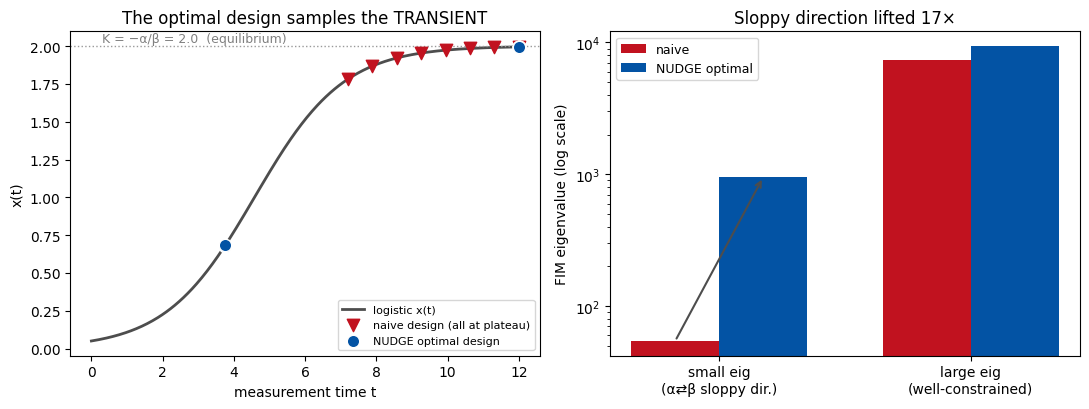

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Left: the trajectory + where each design samples ---
grid_dense = np.linspace(0, t_max, 400)
theta0 = prob.theta0
a, b = np.exp(theta0[0]), -np.exp(theta0[1])
# integrate the logistic analytically for the plot: x(t)=K/(1+((K-x0)/x0)e^{-a t}), K=-a/b
K = -a / b
x0 = prob.meta["x0"]
x_dense = K / (1 + ((K - x0) / x0) * np.exp(-a * grid_dense))
axL.plot(grid_dense, x_dense, color="0.3", lw=2, label="logistic x(t)")
axL.axhline(K, ls=":", color="0.6", lw=1)
axL.text(0.3, K + 0.03, f"K = −α/β = {K:.1f}  (equilibrium)", color="0.5", fontsize=9)


def _x_at(ts):
    return K / (1 + ((K - x0) / x0) * np.exp(-a * np.asarray(ts)))


axL.scatter(phi_naive, _x_at(phi_naive), s=80, color="#c1121f", zorder=5,
            label="naive design (all at plateau)", marker="v")
axL.scatter(res_d.phi_opt, _x_at(res_d.phi_opt), s=80, color="#0353a4", zorder=5,
            label="NUDGE optimal design", marker="o", edgecolor="white")
axL.set_xlabel("measurement time t"); axL.set_ylabel("x(t)")
axL.set_title("The optimal design samples the TRANSIENT")
axL.legend(fontsize=8, loc="lower right")

# --- Right: FIM eigenvalues, naive vs optimal ---
ev_naive = np.sort(np.linalg.eigvalsh(fim_naive))
ev_opt = np.sort(np.linalg.eigvalsh(res_d.fim_opt))
xpos = np.arange(2)
w = 0.35
axR.bar(xpos - w / 2, ev_naive, w, color="#c1121f", label="naive")
axR.bar(xpos + w / 2, ev_opt, w, color="#0353a4", label="NUDGE optimal")
axR.set_yscale("log")
axR.set_xticks(xpos)
axR.set_xticklabels(["small eig\n(α⇄β sloppy dir.)", "large eig\n(well-constrained)"])
axR.set_ylabel("FIM eigenvalue (log scale)")
axR.set_title(f"Sloppy direction lifted {res_d.min_eig_improvement:.0f}×")
axR.legend(fontsize=9)
axR.annotate("", xy=(0 + w / 2, ev_opt[0]), xytext=(0 - w / 2, ev_naive[0]),
             arrowprops=dict(arrowstyle="->", color="0.3", lw=1.5))
fig.tight_layout()
plt.show()

## 3 · At scale — the same FIM, computed matrix-free

The object the OED gradient differentiates is `FIM = JᵀJ/σ²`, the Gram matrix of the sensitivity
`J = ∂observe/∂θ`. On a large ODE network the obvious way to build `J` — forward-mode `jacfwd` —
materializes a per-parameter trajectory, so its memory grows `∝ n_params · n_steps · n_states`
and eventually **OOMs**. NUDGE's identifiability path computes the *same* spectrum **matrix-free**:
it touches the FIM only through matvecs `JᵀJ·v` (one `jvp` composed with one `vjp`), **never
forming `J`**, so its memory is `O(n_params + n_obs)` — flat.

Below is the **measured** scaling (`scripts/vv/sloppiness_scaling.py`, a 77-state gLV under a
2.5 GB cap). The dense `jacfwd` path OOMs at `n_params = 4000`; the matrix-free path stays flat at
~0.42 GB out to 6000 parameters — returning the same `unidentifiable` verdict.

In [7]:
results = json.loads(
    Path("../scripts/vv/sloppiness_scaling_RESULTS.json").read_text()
)
dense = {r["n_theta"]: r for r in results["rows"] if r["method"] == "dense"}
mf = {r["n_theta"]: r for r in results["rows"] if r["method"] == "matrixfree"}
sweep = results["sweep"]

print(f"77-state gLV · dense cap = {results['dense_cap_gb']} GB\n")
print(f"{'n_params':>9} | {'dense jacfwd':>22} | {'matrix-free':>22}")
print("-" * 60)
for n in sweep:
    d, m = dense[n], mf[n]
    d_str = ("OOM (killed)" if d["status"] == "oom"
             else f"{d['wall_s']:5.1f}s / {d['peak_rss_mb']:6.0f} MB")
    m_str = f"{m['wall_s']:5.1f}s / {m['peak_rss_mb']:6.0f} MB  ✓"
    print(f"{n:>9} | {d_str:>22} | {m_str:>22}")

print(f"\ndense OOMs at n_params = {results['dense_oom_min_ntheta']}; "
      f"matrix-free RSS flatness (max/min) = {results['mf_rss_flatness']:.2f}× "
      f"→ {results['verdict']}")
assert results["dense_oom_min_ntheta"] <= 4000, "dense must OOM in the measured sweep"
assert results["mf_rss_flatness"] < 1.2, "matrix-free memory must stay flat"


77-state gLV · dense cap = 2.5 GB

 n_params |           dense jacfwd |            matrix-free
------------------------------------------------------------
      500 |       4.5s /    762 MB |    2.5s /    427 MB  ✓
     1000 |      10.2s /   1145 MB |    2.6s /    443 MB  ✓
     2000 |      29.5s /   1951 MB |    2.9s /    432 MB  ✓
     4000 |           OOM (killed) |    3.2s /    419 MB  ✓
     6000 |           OOM (killed) |    3.5s /    425 MB  ✓

dense OOMs at n_params = 4000; matrix-free RSS flatness (max/min) = 1.06× → MATRIX-FREE FLAT + SCALES PAST DENSE OOM


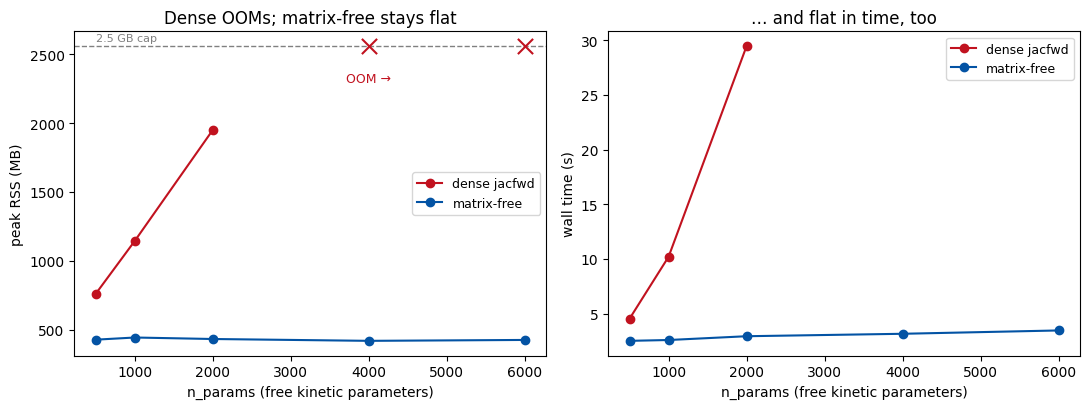

In [8]:
fig, (axM, axT) = plt.subplots(1, 2, figsize=(11, 4.2))
sweep_arr = np.array(sweep)

# peak RSS
d_rss = np.array([dense[n]["peak_rss_mb"] if dense[n]["status"] == "ok" else np.nan
                  for n in sweep])
m_rss = np.array([mf[n]["peak_rss_mb"] for n in sweep])
axM.plot(sweep_arr, d_rss, "o-", color="#c1121f", label="dense jacfwd")
axM.plot(sweep_arr, m_rss, "o-", color="#0353a4", label="matrix-free")
axM.axhline(results["dense_cap_gb"] * 1024, ls="--", color="0.5", lw=1)
axM.text(sweep_arr[0], results["dense_cap_gb"] * 1024 + 40,
         f"{results['dense_cap_gb']} GB cap", color="0.5", fontsize=8)
oom_n = [n for n in sweep if dense[n]["status"] == "oom"]
for n in oom_n:
    axM.scatter([n], [results["dense_cap_gb"] * 1024], marker="x", s=120,
                color="#c1121f", zorder=6)
axM.text(oom_n[0], results["dense_cap_gb"] * 1024 - 260, "OOM →", color="#c1121f",
         fontsize=9, ha="center")
axM.set_xlabel("n_params (free kinetic parameters)")
axM.set_ylabel("peak RSS (MB)")
axM.set_title("Dense OOMs; matrix-free stays flat")
axM.legend(fontsize=9)

# wall time
d_wall = np.array([dense[n]["wall_s"] if dense[n]["status"] == "ok" else np.nan
                   for n in sweep])
m_wall = np.array([mf[n]["wall_s"] for n in sweep])
axT.plot(sweep_arr, d_wall, "o-", color="#c1121f", label="dense jacfwd")
axT.plot(sweep_arr, m_wall, "o-", color="#0353a4", label="matrix-free")
axT.set_xlabel("n_params (free kinetic parameters)")
axT.set_ylabel("wall time (s)")
axT.set_title("… and flat in time, too")
axT.legend(fontsize=9)
fig.tight_layout()
plt.show()

## The moat, assembled

| move | black-box ODE solver | **NUDGE (differentiable JAX)** |
|---|---|---|
| improve an experiment | grid-search — `rᵐ` evals, exponential in design size | **`∂(D-optimality)/∂φ` by autodiff** — one pass, any design dim |
| resolve the sloppy `α` | (must guess where to sample) | **CRLB(α) 31.3× / 31.5× better**, measured at θ₀ |
| identifiability at scale | dense `J` OOMs (`∝ n_params·n_steps·n_states`) | **matrix-free `JᵀJ·v`** — flat ~0.42 GB past dense's OOM |

**Why it holds together:** the *same* differentiability that lets NUDGE fit the model also lets it
differentiate the *experiment design criterion* — and the *same* FIM = `JᵀJ` that the OED gradient
uses is computed matrix-free, so the moat does not close at network scale.

**The honest bounds (load-bearing).** This is **local OED** (`NUDGE-LIM-024`): the optimum and every
gain are measured at the nominal `θ₀`, never extrapolated; near-singular FIMs use a guarded ridge
(so an unresolved design's CRLB is over-cautious, never false-precise); and a black-box grid is
shipped to *check* the gradient optimum. The matrix-free path (`NUDGE-LIM-023`) **abstains** on the
smallest FIM eigenvalue it cannot certify by iteration rather than assert identifiability.

**Reproduce.**
- OED: `nudge oed --model logistic --objective d_opt` · `nudge oed --model glv` (600× on a 3-taxon
  community) · MCP tool `oed` · `service.oed_demo()`.
- Matrix-free scaling: `uv run python scripts/vv/sloppiness_scaling.py`.
- Numbers mirror `tests/inference/test_oed.py`, `tests/inference/test_sloppiness_matrixfree.py`,
  and `scripts/vv/FINDINGS.md` ("Optimal Experimental Design" / "Matrix-free identifiability").